In [1]:
%pip install mlxtend
%pip install - -upgrade pip
%pip install networkx
%pip install openpyxl


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

Usage:   
  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install [options] <requirement specifier> [package-index-options] ...
  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install [options] -r <requirements file> [package-index-options] ...
  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install [options] [-e] <vcs project url> ...
  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install [options] [-e] <local project path> ...
  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install [options] <archive url/path> ...

no such option: -u
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use 

In [2]:
import pandas as pd
from pandas.io.formats.style import Styler
import seaborn as sns
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import networkx as nx
%matplotlib inline
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from mlxtend.frequent_patterns import fpgrowth, association_rules, apriori

pd.set_option("display.max_columns", 300)

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14074/4229447271.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
vlna_4 = pd.read_excel("4. vlna všetko 28-11-2024.xlsx")  
vlna_4

,Poradie,Meno,Pohlavie,Vek,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,HLN Dg.,Diagnózy,DRG výkony,Liečba,SVLZ správy,Mikrobiológia,Epikríza,Terajšie ochorenie,Dôvod hospitalizácie,Objektívny nález,Osobná anamnéza,Lieková anamnéza,Návyková anamnéza,Epidemiologická anamnéza,A04.7,Unnamed: 23,Závažnosť priebehu ochorenia,Fajčenie,Alkohol,S-Bil-T first,S-Bil-T last,S-Bil-T min,S-Bil-T max,S-AST first,S-AST last,S-AST min,S-AST max,S-ALT first,S-ALT last,S-ALT min,S-ALT max,S-GMT first,S-GMT last,S-GMT min,S-GMT max,S-ALP first,S-ALP last,S-ALP min,S-ALP max,S-Chol first,S-Chol last,S-Chol min,S-Chol max,S-CB first,S-CB last,S-CB min,S-CB max,S-Na first,S-Na last,S-Na min,S-Na max,S-K first,S-K last,S-K min,S-K max,S-CL first,S-CL last,S-CL min,S-CL max,S-IgG first,S-IgG last,S-IgG min,S-IgG max,S-IgA first,S-IgA last,S-IgA min,S-IgA max,S-Ig M first,S-Ig M last,S-Ig M min,S-Ig M max,S-CRP first,S-CRP last,S-CRP min,S-CRP max,S-Alb first,S-Alb last,S-Alb min,S-Alb max,S-Gluk first,S-Gluk last,S-Gluk min,S-Gluk max,S-Urea first,S-Urea last,S-Urea min,S-Urea max,S-Kreat first,S-Kreat last,S-Kreat min,S-Kreat max,S-KM first,S-KM last,S-KM min,S-KM max,S-AMS first,S-AMS last,S-AMS min,S-AMS max,S-CK first,S-CK last,S-CK min,S-CK max,S-CK-MB first,S-CK-MB last,S-CK-MB min,S-CK-MB max,S-LD first,S-LD last,S-LD min,S-LD max,P-Laktát first,P-Laktát last,P-Laktát min,P-Laktát max,S-FER first,S-FER last,S-FER min,S-FER max,S-IL6 first,S-IL6 last,S-IL6 min,S-IL6 max,HGB first,HGB last,HGB min,HGB max,WBC first,WBC last,WBC min,WBC max,PLT first,PLT last,PLT min,PLT max,Neu abs first,Neu abs last,Neu abs min,Neu abs max,Eo abs first,Eo abs last,Eo abs min,Eo abs max,Ly abs first,Ly abs last,Ly abs min,Ly abs max,PT (INR) first,PT (INR) last,PT (INR) min,PT (INR) max,APTT-R first,APTT-R last,APTT-R min,APTT-R max,Fib first,Fib last,Fib min,Fib max,CD3+ first,CD3+ last,CD3+ min,CD3+ max,CD4+ first,CD4+ last,CD4+ min,CD4+ max,CD8+ first,CD8+ last,CD8+ min,CD8+ max,CD4+/CD8+ first,CD4+/CD8+ last,CD4+/CD8+ min,CD4+/CD8+ max,PDW first,PDW last,PDW min,PDW max,CD19+ first,CD19+ last,CD19+ min,CD19+ max,NK first,NK last,NK min,NK max,NE/LY(NLR) first,NE/LY(NLR) last,NE/LY(NLR) min,NE/LY(NLR) max,D-dimér HS first,D-dimér HS last,D-dimér HS min,D-dimér HS max,SatO2 %,Hypertenzia,Diabetes mellitus,Kardiovaskulárne ochorenia,Chronické respiračné ochorenia,Renálne ochorenia,Pečeňové ochorenia,Onkologické ochorenia,Imunosupresia,Vakcinácia,Typ vakcíny,Počet dávok,MD652 | FABIFLU TABLETS,MD656 IV-BECT 6MG (ivermectin),5042D | VEKLURY,9547D | PAXLOVID,LAGEVRIO,00584 | PYRIDOXIN LÉČIVA INJ,24836 | ACIDUM ASCORBICUM BBP,"24814 | CALCIFEROL BBP 7,5 MG/ML",00498 | MAGNESIUM SULFURICUM BBP 100 MG/ML INJEKČNÝ ROZTOK,00449 | EREVIT 300 MG/ML,89145 | VITAMIN C-INJEKTOPAS,92973 ALPHA D3,02963 | PREDNISON 20 LÉČIVA,00269 | PREDNISON 5 LÉČIVA,84090 | DEXAMED 6,1275C | DEXAMETAZÓN KRKA,MD661 BIODEXONE-DEXAMETHASONE,2410B HYDROCORTISONE,3242C | OLUMIANT 4 MG,Anakinra,RoActemra,34045 | POLYOXIDONIUM 6 MG,87299 | IMUNOR,56930 IMMODIN,"Isoprinosine,",3879d INOMED,35715 Azithromycin,45954 Ceftriaxon,0471B MOLOXIN,9819A MOXIFLOXACIN,58730 CIPROFLOXACIN KABI 200,58746 CIPROFLOXACINKABI 400,05044 OZZION,4147C OMEMYL,89662 NOLPAZA,39397 PANTOPRAZOL,62916 SMECTA,30639 REASEC,84370 LAGOSA,93105 DEGAN,94918 AMBROBENE,24859 PENTOXYPHILLINUM,8893 ACC INJEKT,24949 CODEIN,26846 OXANTIL,FRAXIPARIN,CLEXANE,FRAGMIN,ASPIRIN,ANOPYRIN,Prekonal COVID-19,S-PBNP first,S-PBNP last,S-PBNP min,S-PBNP max,S-VITD first,S-VITD last,S-VITD min,S-VITD max
0,1,TOHAMJTTYUMQPEAPLOLF,Žena,67,01.01.2022,1,10.01.2022,7,J12.8 | Iný vírusový zápal pľúc | B,U07.3 | Potvrdená infekcia COVID-19 PCR testom...,8p100.6 | Ventilačná podpora vysokým prietokom...,01125 | MORPHIN BIOTIKA 1% | 3; _x000D_\n02479...,"Popis: 03.01.2022 | RTG ko., porovnávané s vyš...",02.01.2022 07:31:00 | zaplava amorf. soli ; _x...,"Epikríza: 67- ročná obézna pacientka, neočkova...","TO: Chorá sa cíti od 27.12.2021, má teplo

In [ ]:
# Odstránenie identifikátorov
drop_cols = ["Poradie", "Meno"]
vlna_4 = vlna_4.drop(columns=drop_cols, errors="ignore")

In [5]:
vlna_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1251 entries, 0 to 1250
Columns: 272 entries, Pohlavie to S-VITD max
dtypes: bool(63), float64(187), int64(4), object(18)
memory usage: 2.1+ MB


In [6]:
vlna_4

,Pohlavie,Vek,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,HLN Dg.,Diagnózy,DRG výkony,Liečba,SVLZ správy,Mikrobiológia,Epikríza,Terajšie ochorenie,Dôvod hospitalizácie,Objektívny nález,Osobná anamnéza,Lieková anamnéza,Návyková anamnéza,Epidemiologická anamnéza,A04.7,Unnamed: 23,Závažnosť priebehu ochorenia,Fajčenie,Alkohol,S-Bil-T first,S-Bil-T last,S-Bil-T min,S-Bil-T max,S-AST first,S-AST last,S-AST min,S-AST max,S-ALT first,S-ALT last,S-ALT min,S-ALT max,S-GMT first,S-GMT last,S-GMT min,S-GMT max,S-ALP first,S-ALP last,S-ALP min,S-ALP max,S-Chol first,S-Chol last,S-Chol min,S-Chol max,S-CB first,S-CB last,S-CB min,S-CB max,S-Na first,S-Na last,S-Na min,S-Na max,S-K first,S-K last,S-K min,S-K max,S-CL first,S-CL last,S-CL min,S-CL max,S-IgG first,S-IgG last,S-IgG min,S-IgG max,S-IgA first,S-IgA last,S-IgA min,S-IgA max,S-Ig M first,S-Ig M last,S-Ig M min,S-Ig M max,S-CRP first,S-CRP last,S-CRP min,S-CRP max,S-Alb first,S-Alb last,S-Alb min,S-Alb max,S-Gluk first,S-Gluk last,S-Gluk min,S-Gluk max,S-Urea first,S-Urea last,S-Urea min,S-Urea max,S-Kreat first,S-Kreat last,S-Kreat min,S-Kreat max,S-KM first,S-KM last,S-KM min,S-KM max,S-AMS first,S-AMS last,S-AMS min,S-AMS max,S-CK first,S-CK last,S-CK min,S-CK max,S-CK-MB first,S-CK-MB last,S-CK-MB min,S-CK-MB max,S-LD first,S-LD last,S-LD min,S-LD max,P-Laktát first,P-Laktát last,P-Laktát min,P-Laktát max,S-FER first,S-FER last,S-FER min,S-FER max,S-IL6 first,S-IL6 last,S-IL6 min,S-IL6 max,HGB first,HGB last,HGB min,HGB max,WBC first,WBC last,WBC min,WBC max,PLT first,PLT last,PLT min,PLT max,Neu abs first,Neu abs last,Neu abs min,Neu abs max,Eo abs first,Eo abs last,Eo abs min,Eo abs max,Ly abs first,Ly abs last,Ly abs min,Ly abs max,PT (INR) first,PT (INR) last,PT (INR) min,PT (INR) max,APTT-R first,APTT-R last,APTT-R min,APTT-R max,Fib first,Fib last,Fib min,Fib max,CD3+ first,CD3+ last,CD3+ min,CD3+ max,CD4+ first,CD4+ last,CD4+ min,CD4+ max,CD8+ first,CD8+ last,CD8+ min,CD8+ max,CD4+/CD8+ first,CD4+/CD8+ last,CD4+/CD8+ min,CD4+/CD8+ max,PDW first,PDW last,PDW min,PDW max,CD19+ first,CD19+ last,CD19+ min,CD19+ max,NK first,NK last,NK min,NK max,NE/LY(NLR) first,NE/LY(NLR) last,NE/LY(NLR) min,NE/LY(NLR) max,D-dimér HS first,D-dimér HS last,D-dimér HS min,D-dimér HS max,SatO2 %,Hypertenzia,Diabetes mellitus,Kardiovaskulárne ochorenia,Chronické respiračné ochorenia,Renálne ochorenia,Pečeňové ochorenia,Onkologické ochorenia,Imunosupresia,Vakcinácia,Typ vakcíny,Počet dávok,MD652 | FABIFLU TABLETS,MD656 IV-BECT 6MG (ivermectin),5042D | VEKLURY,9547D | PAXLOVID,LAGEVRIO,00584 | PYRIDOXIN LÉČIVA INJ,24836 | ACIDUM ASCORBICUM BBP,"24814 | CALCIFEROL BBP 7,5 MG/ML",00498 | MAGNESIUM SULFURICUM BBP 100 MG/ML INJEKČNÝ ROZTOK,00449 | EREVIT 300 MG/ML,89145 | VITAMIN C-INJEKTOPAS,92973 ALPHA D3,02963 | PREDNISON 20 LÉČIVA,00269 | PREDNISON 5 LÉČIVA,84090 | DEXAMED 6,1275C | DEXAMETAZÓN KRKA,MD661 BIODEXONE-DEXAMETHASONE,2410B HYDROCORTISONE,3242C | OLUMIANT 4 MG,Anakinra,RoActemra,34045 | POLYOXIDONIUM 6 MG,87299 | IMUNOR,56930 IMMODIN,"Isoprinosine,",3879d INOMED,35715 Azithromycin,45954 Ceftriaxon,0471B MOLOXIN,9819A MOXIFLOXACIN,58730 CIPROFLOXACIN KABI 200,58746 CIPROFLOXACINKABI 400,05044 OZZION,4147C OMEMYL,89662 NOLPAZA,39397 PANTOPRAZOL,62916 SMECTA,30639 REASEC,84370 LAGOSA,93105 DEGAN,94918 AMBROBENE,24859 PENTOXYPHILLINUM,8893 ACC INJEKT,24949 CODEIN,26846 OXANTIL,FRAXIPARIN,CLEXANE,FRAGMIN,ASPIRIN,ANOPYRIN,Prekonal COVID-19,S-PBNP first,S-PBNP last,S-PBNP min,S-PBNP max,S-VITD first,S-VITD last,S-VITD min,S-VITD max
0,Žena,67,01.01.2022,1,10.01.2022,7,J12.8 | Iný vírusový zápal pľúc | B,U07.3 | Potvrdená infekcia COVID-19 PCR testom...,8p100.6 | Ventilačná podpora vysokým prietokom...,01125 | MORPHIN BIOTIKA 1% | 3; _x000D_\n02479...,"Popis: 03.01.2022 | RTG ko., porovnávané s vyš...",02.01.2022 07:31:00 | zaplava amorf. soli ; _x...,"Epikríza: 67- ročná obézna pacientka, neočkova...","TO: Chorá sa cíti od 27.12.2021, má teploty do...",Dôvod hospitalizácie: Paci

In [7]:
print(vlna_4.Pohlavie.value_counts())
print(vlna_4.Vek.value_counts())

Pohlavie
Žena    639
Muž     612
Name: count, dtype: int64
Vek
79     49
81     47
70     46
82     45
84     44
       ..
99      1
29      1
100     1
22      1
97      1
Name: count, Length: 75, dtype: int64


In [8]:
print(vlna_4["Závažnosť priebehu ochorenia"].value_counts())

Závažnosť priebehu ochorenia
1.0    907
2.0    213
3.0    128
Name: count, dtype: int64


In [ ]:
# Funkcia na nahradenie nezmyselných hodnôt 'Other' najčastejšou hodnotou pre daný atribút
def nahradenie(vlna_4, column_name):
    most_common_value = vlna_4[column_name].mode()[0]
    vlna_4.loc[vlna_4[column_name] == 'Other', column_name] = most_common_value
    return most_common_value

print("Najčastejšia hodnota pre 'vek':")
najcastejsi_vek = nahradenie(vlna_4, 'Vek')
print(najcastejsi_vek)

Najčastejšia hodnota pre 'vek':
79


/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14074/3342031314.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=vlna_4, x="Pohlavie", ax=ax, palette='flare')


Text(0.5, 1.0, 'Pacienti podľa pohlavia')

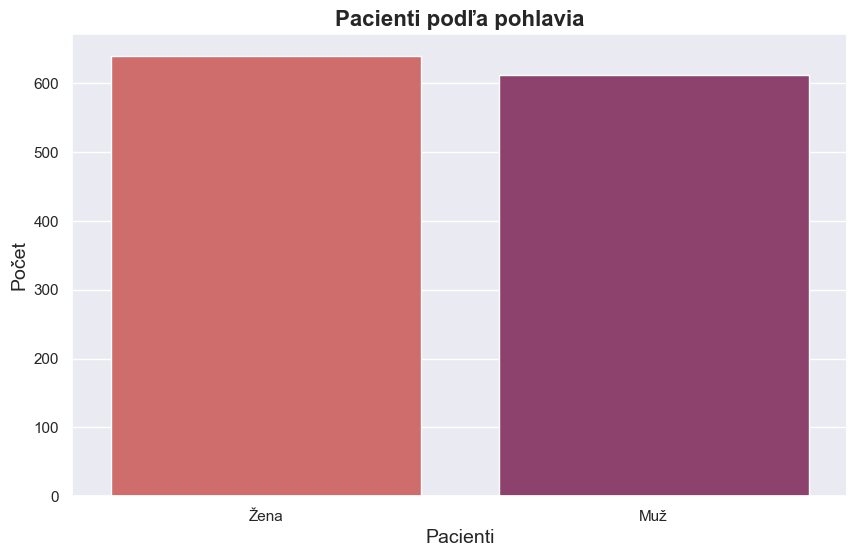

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Pacienti podľa pohlavia
sns.countplot(data=vlna_4, x="Pohlavie", ax=ax, palette='flare')
ax.set_xlabel("Pacienti", fontsize=14)
ax.set_ylabel("Počet", fontsize=14)
ax.set_title("Pacienti podľa pohlavia", fontsize=16, fontweight='bold')

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14074/3701052748.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=vlna_4, y="vekova_skupina", palette='flare')


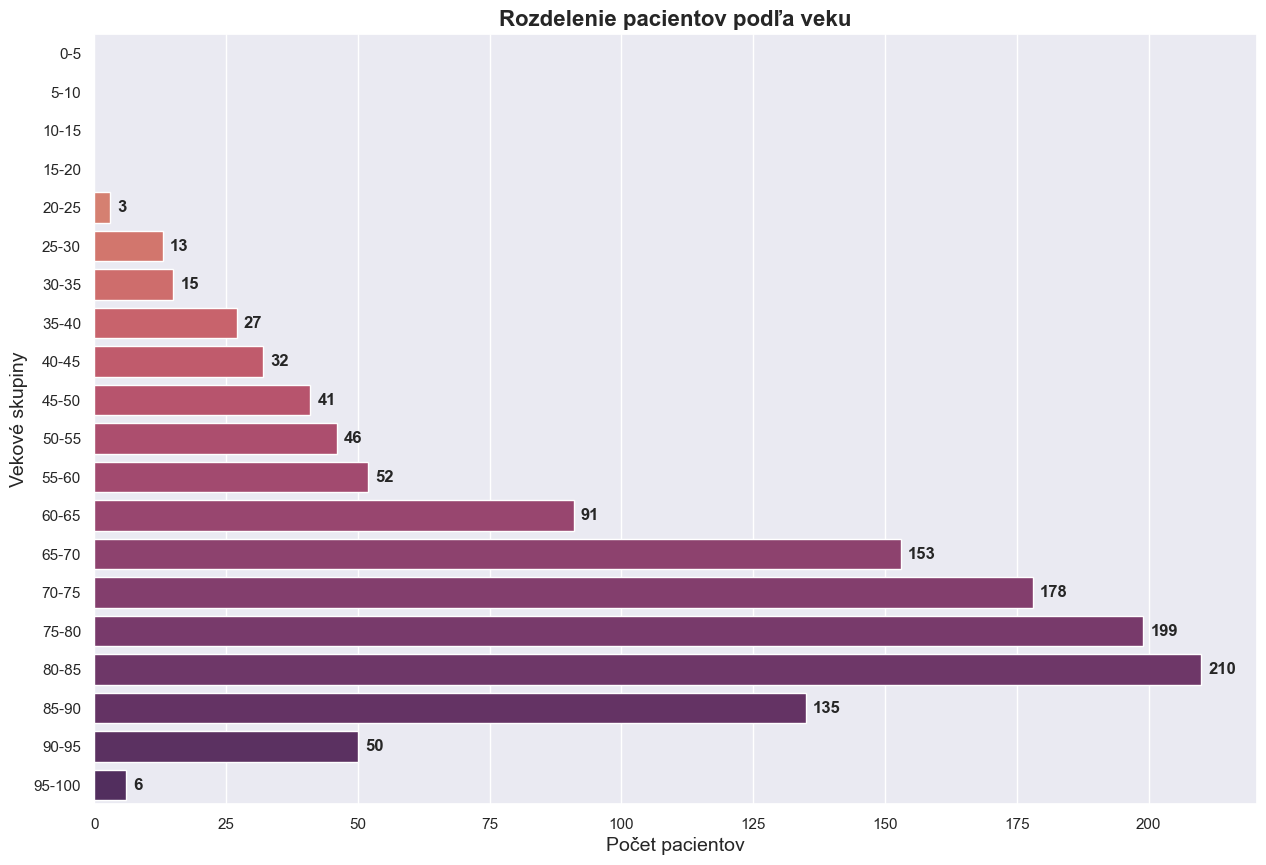

In [ ]:
# HISTOGRAM - rozdelenie pacientov do vekových skupín
# Definovanie hraníc od 0 do 100 s krokom 5
bins = list(range(0, 101, 5)) 

# Automatické vygenerovanie labelov vo formáte '0-5', '5-10', atď.
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
vlna_4['vekova_skupina'] = pd.cut(vlna_4['Vek'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(15, 10))
ax = sns.countplot(data=vlna_4, y="vekova_skupina", palette='flare')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.xlabel("Počet pacientov", fontsize=14)
plt.ylabel("Vekové skupiny", fontsize=14)
plt.title("Rozdelenie pacientov podľa veku", fontsize=16, fontweight='bold')
plt.show()


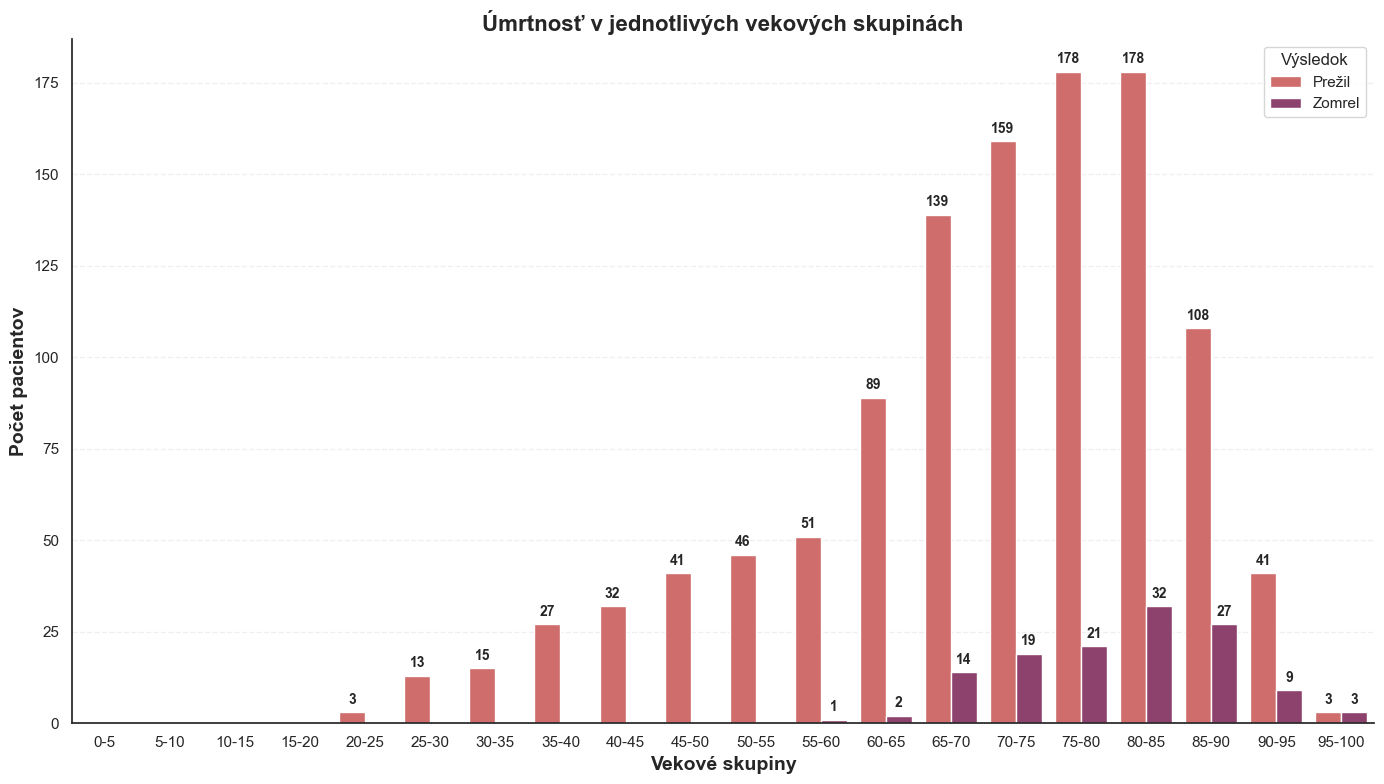

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white") 

if 'Zomrel' not in vlna_4.columns:
    if 'Závažnosť priebehu ochorenia' in vlna_4.columns:
        vlna_4['Zomrel'] = (vlna_4['Závažnosť priebehu ochorenia'] == 3)
    else:
        print("Chyba: Stĺpec 'Zomrel' sa nenašiel. Dostupné stĺpce sú:", vlna_4.columns.tolist())

# Príprava stĺpca 'Stav' a kontrola typov
vlna_4['Zomrel'] = vlna_4['Zomrel'].astype(int)
vlna_4['Stav'] = vlna_4['Zomrel'].map({1: 'Zomrel', 0: 'Prežil'})

# VYKRESLENIE
plt.figure(figsize=(14, 8), facecolor='white') 

ax = sns.countplot(data=vlna_4, x="vekova_skupina", hue="Stav", 
                   palette='flare', hue_order=['Prežil', 'Zomrel'])

sns.despine()


plt.xlabel("Vekové skupiny", fontsize=14, fontweight='bold')
plt.ylabel("Počet pacientov", fontsize=14, fontweight='bold')
plt.title("Úmrtnosť v jednotlivých vekových skupinách", fontsize=16, fontweight='bold')
plt.legend(title="Výsledok")

plt.grid(axis='y', linestyle='--', alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

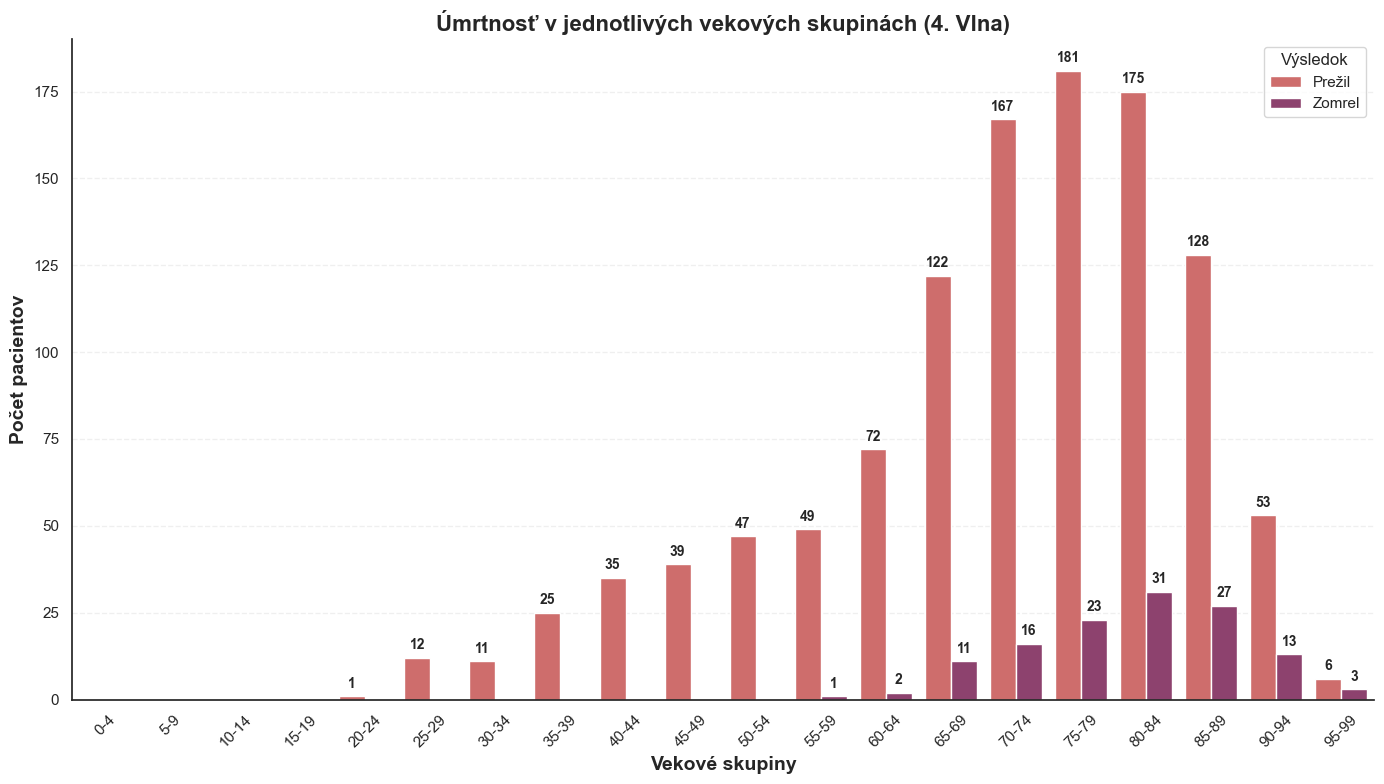

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_style("white") 

if 'Zomrel' not in vlna_4.columns:
    if 'Závažnosť priebehu ochorenia' in vlna_4.columns:
        vlna_4['Zomrel'] = (vlna_4['Závažnosť priebehu ochorenia'] == 3).astype(int)
    else:
        print("Chyba: Stĺpec 'Zomrel' sa nenašiel.")

# Vytvorenie 5-ročných intervalov (0-4, 5-9, ...)
bins = list(range(0, 105, 5))
labels = [f"{i}-{i+4}" for i in range(0, 100, 5)]
vlna_4['vek_5_rocne'] = pd.cut(vlna_4['Vek'], bins=bins, labels=labels, right=False)

# Príprava stĺpca 'Stav' a kontrola typov
vlna_4['Zomrel'] = vlna_4['Zomrel'].astype(int)
vlna_4['Stav'] = vlna_4['Zomrel'].map({1: 'Zomrel', 0: 'Prežil'})

# VYKRESLENIE
plt.figure(figsize=(14, 8), facecolor='white') 

ax = sns.countplot(data=vlna_4, x="vek_5_rocne", hue="Stav", 
                   palette='flare', hue_order=['Prežil', 'Zomrel'])

sns.despine()

plt.xlabel("Vekové skupiny", fontsize=14, fontweight='bold')
plt.ylabel("Počet pacientov", fontsize=14, fontweight='bold')
plt.title("Úmrtnosť v jednotlivých vekových skupinách (4. Vlna)", fontsize=16, fontweight='bold')
plt.xticks(rotation=45) 
plt.legend(title="Výsledok")

plt.grid(axis='y', linestyle='--', alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# Najmladší pacient
najmladsi = vlna_4["Vek"].min()

# Najstarší pacient
najstarsi = vlna_4["Vek"].max()

print(f"Najmladší pacient má {najmladsi} rokov.")
print(f"Najstarší pacient má {najstarsi} rokov.")

Najmladší pacient má 22 rokov.
Najstarší pacient má 100 rokov.


--- PRÍPRAVA DÁT PRE DALŠIE GRAFY ---

In [15]:
# Prevod dátumov na datetime formát
vlna_4['Dátum príjmu'] = pd.to_datetime(vlna_4['Dátum príjmu'], errors='coerce')
vlna_4['Dátum prepustenia'] = pd.to_datetime(vlna_4['Dátum prepustenia'], errors='coerce')

# Výpočet dĺžky hospitalizácie v dňoch
vlna_4['Dĺžka hospitalizácie'] = (vlna_4['Dátum prepustenia'] - vlna_4['Dátum príjmu']).dt.days

In [16]:
# Nastavenie štýlu grafov
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

VIZUALIZÁCIA
1. graf - závažnosť priebehu ochorenia (bar chart)

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14074/1821713322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=zavaznost_counts.index, y=zavaznost_counts.values, palette='flare')


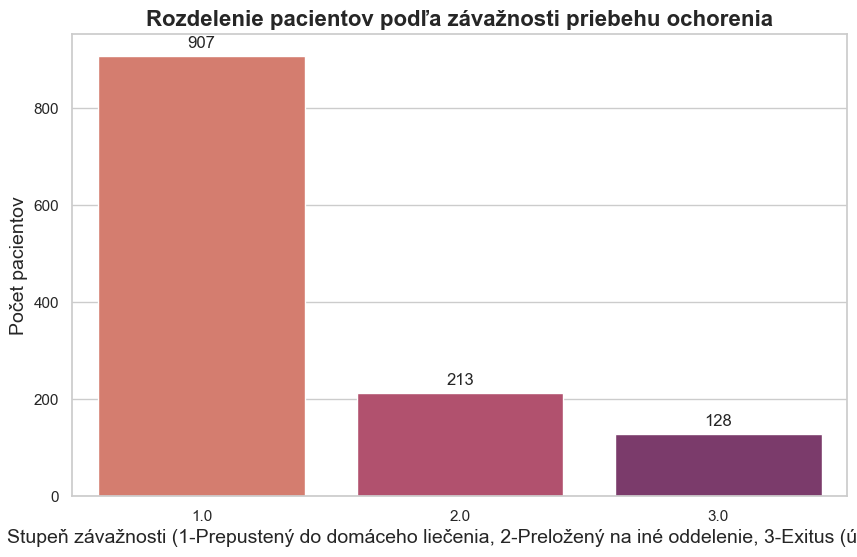

In [ ]:
plt.figure(figsize=(10, 6))
zavaznost_counts = vlna_4['Závažnosť priebehu ochorenia'].value_counts().sort_index()
ax1 = sns.barplot(x=zavaznost_counts.index, y=zavaznost_counts.values, palette='flare')
plt.title('Rozdelenie pacientov podľa závažnosti priebehu ochorenia', fontsize=16, fontweight='bold')
plt.xlabel('Stupeň závažnosti (1-Prepustený do domáceho liečenia, 2-Preložený na iné oddelenie, 3-Exitus (úmrtie))', fontsize=14)
plt.ylabel('Počet pacientov', fontsize=14)

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()


In [18]:
# Zistíme presné počty pre každú hodnotu závažnosti
print(vlna_4['Závažnosť priebehu ochorenia'].value_counts())

# Pozrieme sa, či tam nie sú nejaké chyby (napr. či nie sú tie čísla zapísané ako text)
print(vlna_4['Závažnosť priebehu ochorenia'].unique())

Závažnosť priebehu ochorenia
1.0    907
2.0    213
3.0    128
Name: count, dtype: int64
[ 3.  1.  2. nan]


"Analýza prvej vlny ukázala vysokú koncentráciu pacientov so stupňom závažnosti 3, zatiaľ čo stupne 4 a 5 neboli v sledovanej vzorke zastúpené. Tento fakt naznačuje odlišný manažment pacientov alebo nižšiu virulenciu v porovnaní s nasledujúcimi vlnami, kde budeme sledovať posun k vyššej závažnosti"

2. graf - dĺžka hospitalizácie (boxplot)

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14074/3687996847.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=vlna_4,


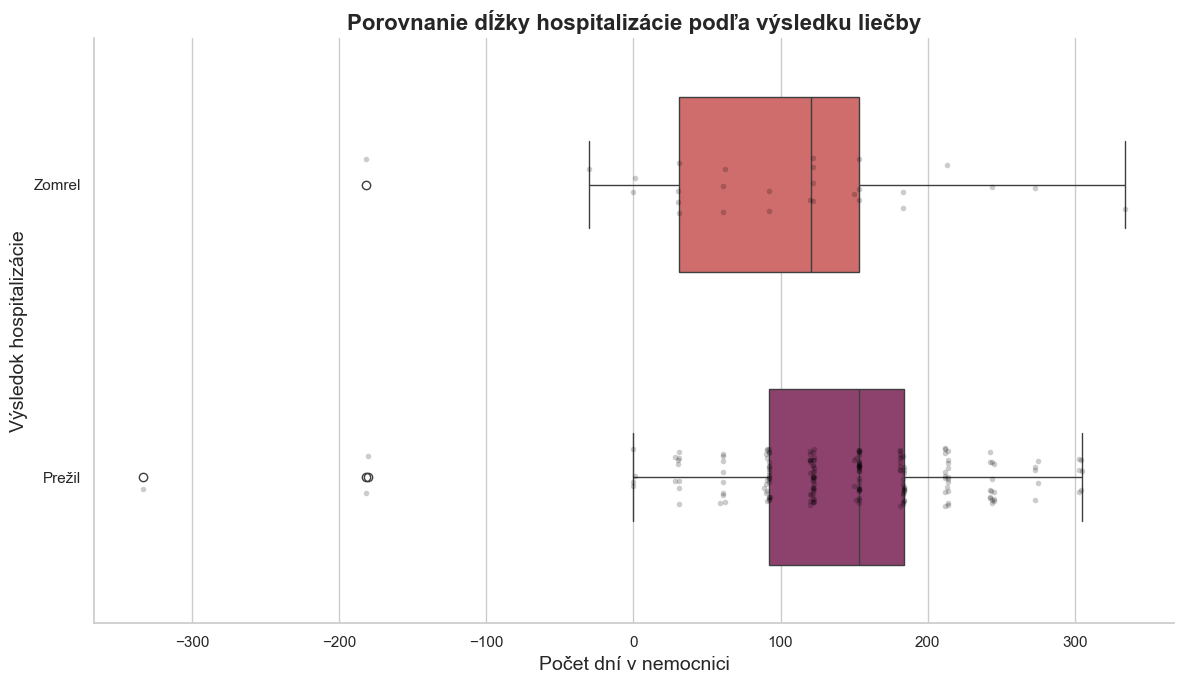

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'Stav' not in vlna_4.columns:
    vlna_4['Stav'] = vlna_4['Zomrel'].map({True: 'Zomrel', False: 'Prežil', 1: 'Zomrel', 0: 'Prežil'})

plt.figure(figsize=(12, 7))

# VYKRESLENIE: Boxplot rozdelený podľa stavu
ax = sns.boxplot(data=vlna_4, 
                 x='Dĺžka hospitalizácie', 
                 y='Stav', 
                 palette="flare",
                 width=0.6)

sns.stripplot(data=vlna_4, 
              x='Dĺžka hospitalizácie', 
              y='Stav', 
              color='black', 
              alpha=0.2, 
              size=4)

plt.title('Porovnanie dĺžky hospitalizácie podľa výsledku liečby', fontsize=16, fontweight='bold')
plt.xlabel('Počet dní v nemocnici', fontsize=14)
plt.ylabel('Výsledok hospitalizácie', fontsize=14)

sns.despine()

plt.tight_layout()
plt.show()

„Tento porovnávací boxplot vizualizuje rozdiel v dĺžke hospitalizácie medzi skupinami pacientov. Vidíme, že skupina pacientov, ktorí ochoreniu podľahli, vykazuje [nižší/vyšší] medián času stráveného v nemocnici. Prítomnosť výrazných odľahlých hodnôt v oboch skupinách potvrdzuje extrémne individuálny priebeh ochorenia COVID-19, kde dĺžka hospitalizácie niekedy presiahla aj 30 a viac dní, čo pravdepodobne súvisí s rozvojom komplikácií.“

In [ ]:
# Výpočet štatistík pre obe skupiny
stats = vlna_4.groupby('Stav')['Dĺžka hospitalizácie'].agg(['mean', 'median', 'std', 'min', 'max', 'count']).round(2)

# Premenovanie stĺpcov pre lepšiu prehľadnosť
stats.columns = ['Priemer (dni)', 'Medián (dni)', 'Smerodajná odchýlka', 'Min', 'Max', 'Počet pacientov']

print("Štatistické porovnanie dĺžky hospitalizácie:")
display(stats)

median_prezil = stats.loc['Prežil', 'Medián (dni)']
median_zomrel = stats.loc['Zomrel', 'Medián (dni)']
rozdiel = abs(median_prezil - median_zomrel)

print(f"\nTIP DO TEXTU:")
print(f"Medián dĺžky hospitalizácie u pacientov, ktorí prežili, bol {median_prezil} dní,")
print(f"zatiaľ čo u pacientov, ktorí zomreli, to bolo {median_zomrel} dní.")
print(f"Rozdiel v mediánoch je {rozdiel} dní.")

Štatistické porovnanie dĺžky hospitalizácie:


,Priemer (dni),Medián (dni),Smerodajná odchýlka,Min,Max,Počet pacientov
Stav,,,,,,
Prežil,143.29,153.0,81.29,-333.0,305.0,199
Zomrel,104.50,121.0,102.71,-182.0,334.0,28



TIP DO TEXTU:
Medián dĺžky hospitalizácie u pacientov, ktorí prežili, bol 153.0 dní,
zatiaľ čo u pacientov, ktorí zomreli, to bolo 121.0 dní.
Rozdiel v mediánoch je 32.0 dní.


- výpočet štatistík - dlžky hospitalizácií pacientov

In [22]:
# Najkratšia hospitalizácia (min automaticky ignoruje NaN)
min_dni = vlna_4['Dĺžka hospitalizácie'].min() 
pocet_min = len(vlna_4[vlna_4['Dĺžka hospitalizácie'] == min_dni])

# Najdlhšia hospitalizácia (max automaticky ignoruje NaN)
max_dni = vlna_4['Dĺžka hospitalizácie'].max() 
pocet_max = len(vlna_4[vlna_4['Dĺžka hospitalizácie'] == max_dni])

# Počet pacientov, ktorí nemajú vyplnenú dĺžku (chýbajúce údaje)
pocet_chybajucich = vlna_4['Dĺžka hospitalizácie'].isna().sum()

print(f"--- Štatistika hospitalizácií ---")
print(f"Najkratšia hospitalizácia trvala: {int(min_dni) if pd.notna(min_dni) else 'N/A'} dní")
print(f"Počet pacientov s touto dĺžkou: {pocet_min}")
print(f"---------------------------------")
print(f"Najdlhšia hospitalizácia trvala: {int(max_dni) if pd.notna(max_dni) else 'N/A'} dní")
print(f"Počet pacientov s touto dĺžkou: {pocet_max}")
print(f"---------------------------------")
print(f"Počet pacientov s nevyplnenou dĺžkou: {pocet_chybajucich}")

--- Štatistika hospitalizácií ---
Najkratšia hospitalizácia trvala: -333 dní
Počet pacientov s touto dĺžkou: 1
---------------------------------
Najdlhšia hospitalizácia trvala: 334 dní
Počet pacientov s touto dĺžkou: 1
---------------------------------
Počet pacientov s nevyplnenou dĺžkou: 1024


3. graf - top 10 komorbidít / diagnóz
- vyberieme stĺpce s diagnózami - ktoré definujeme ako dôležité -> ked sú ako True/False

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14074/3329706488.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=counts.index, palette='flare')


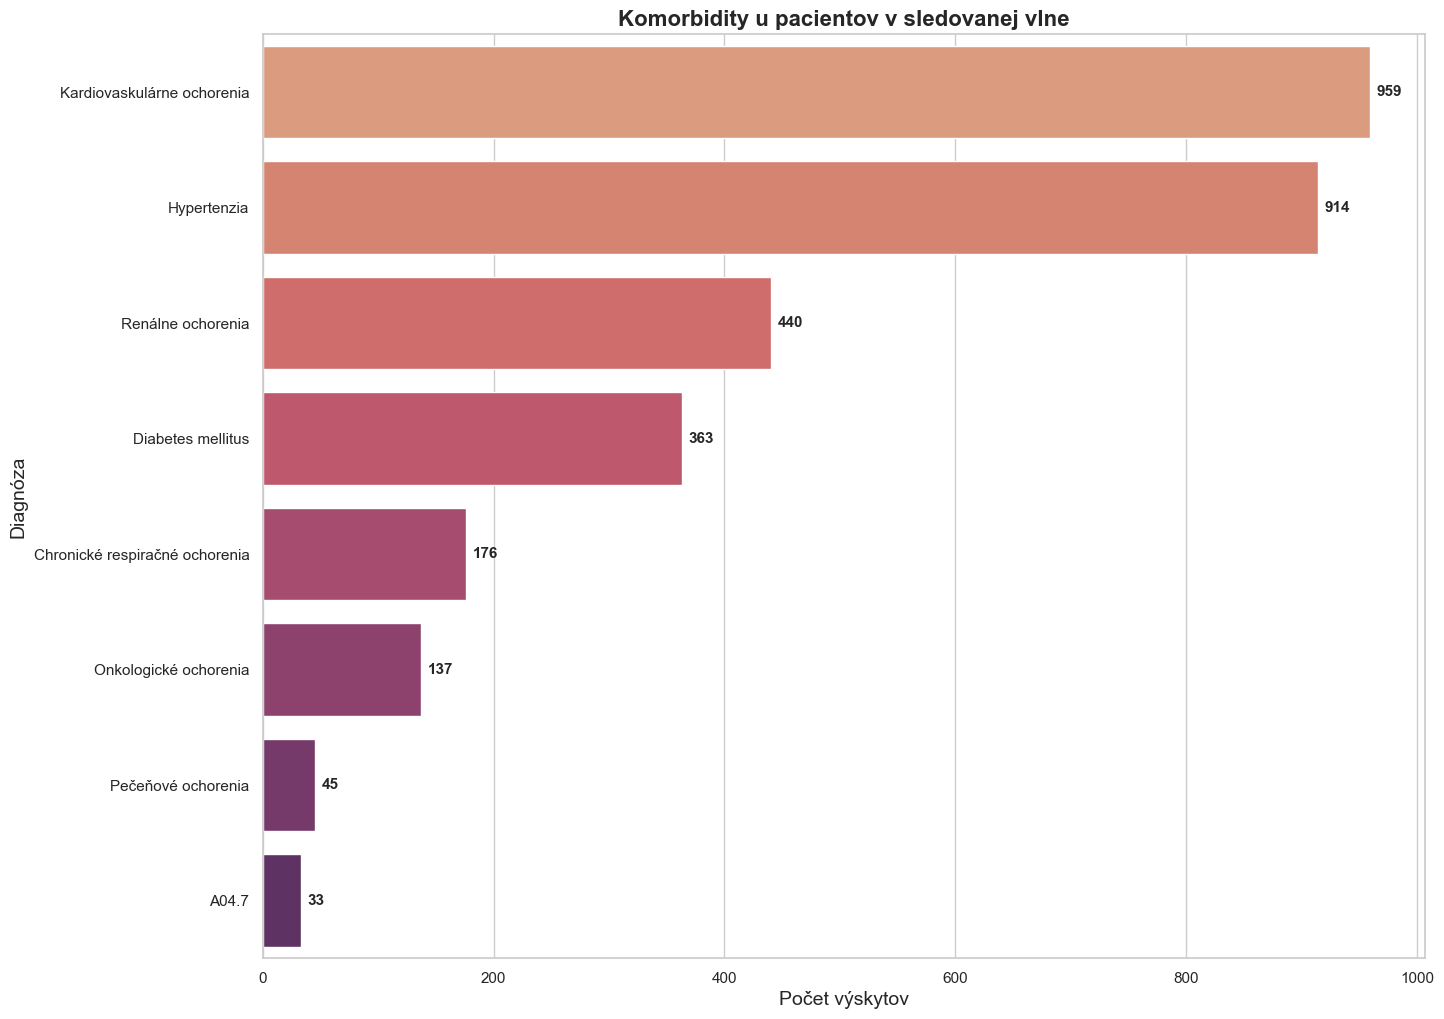

In [ ]:
komorbidity_list = ['Renálne ochorenia', 'Hypertenzia', 'Kardiovaskulárne ochorenia', 'A04.7', "Onkologické ochorenia", "Chronické respiračné ochorenia", "Diabetes mellitus", "Pečeňové ochorenia"]

counts = vlna_4[komorbidity_list].sum().sort_values(ascending=False)
plt.figure(figsize=(15, 12))
ax = sns.barplot(x=counts.values, y=counts.index, palette='flare')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')
    
plt.title('Komorbidity u pacientov v sledovanej vlne', fontsize=16, fontweight='bold')
plt.xlabel('Počet výskytov', fontsize=14)
plt.ylabel('Diagnóza', fontsize=14)
plt.show()

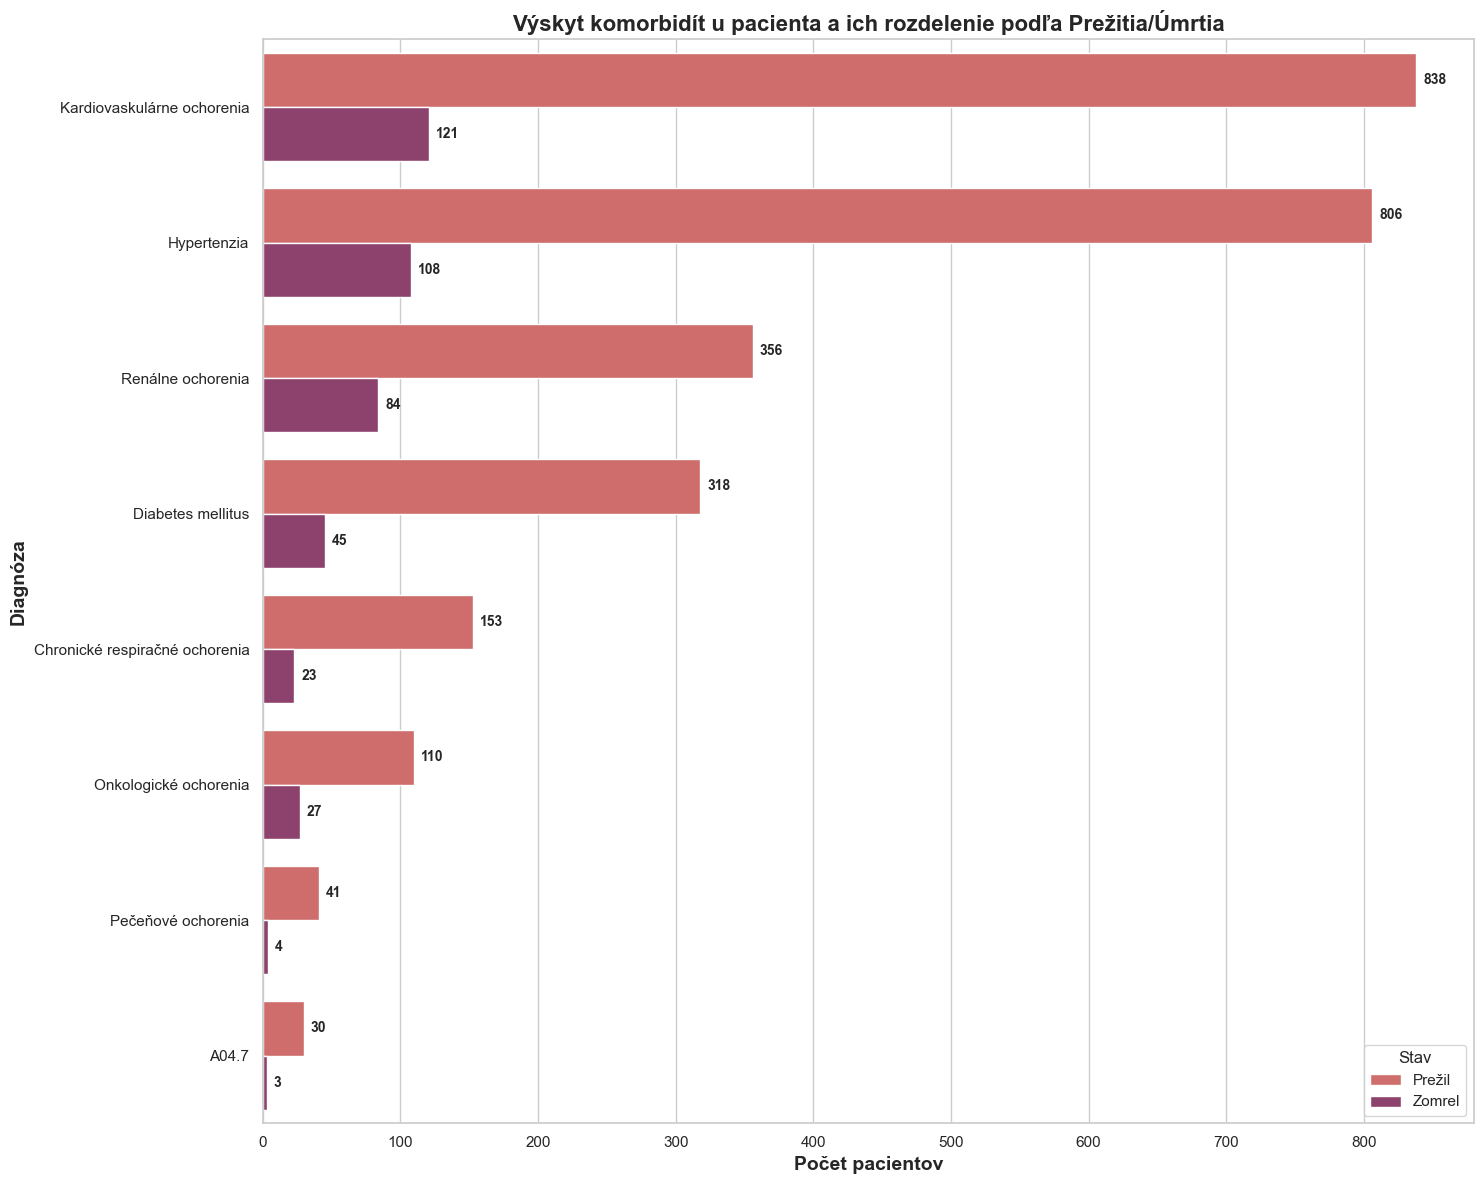

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Príprava dát
# Vyberieme komorbidity a stĺpec 'Úmrtie' (zmeň názov podľa tvojho datasetu)
df_subset = vlna_4[komorbidity_list + ['Zomrel']]

df_melted = df_subset.melt(id_vars='Zomrel', var_name='Komorbidita', value_name='Vyskyt')

df_plot = df_melted[df_melted['Vyskyt'] == 1]

# Vykreslenie grafu
plt.figure(figsize=(15, 12))

ax = sns.countplot(data=df_plot, y='Komorbidita', hue='Zomrel', 
                   palette='flare', order=counts.index)

for p in ax.patches:
    width = p.get_width()
    if width > 0:  
        ax.annotate(f'{int(width)}', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.title('Výskyt komorbidít u pacienta a ich rozdelenie podľa Prežitia/Úmrtia', fontsize=16, fontweight='bold')
plt.xlabel('Počet pacientov', fontsize=14, fontweight='bold')
plt.ylabel('Diagnóza', fontsize=14, fontweight='bold')
plt.legend(title='Stav', labels=['Prežil', 'Zomrel']) 
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


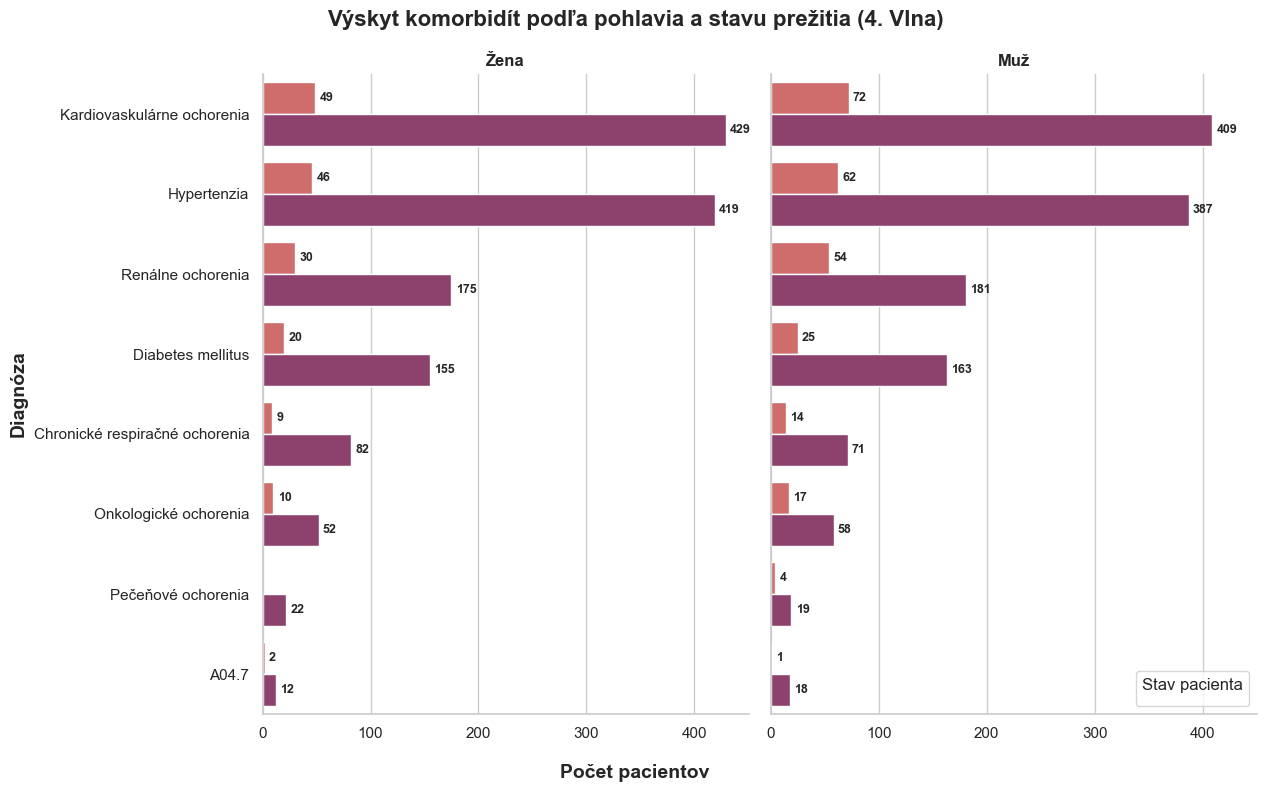

In [ ]:
# Príprava dát
df_subset = vlna_4[komorbidity_list + ['Zomrel', 'Pohlavie']]
df_melted = df_subset.melt(id_vars=['Zomrel', 'Pohlavie'], var_name='Komorbidita', value_name='Vyskyt')

# Vyfiltrujeme len pozitívny výskyt
df_plot = df_melted[df_melted['Vyskyt'] == 1].copy()

df_plot['Zomrel'] = df_plot['Zomrel'].replace({0: 'Prežil', 1: 'Zomrel'})

counts = df_plot['Komorbidita'].value_counts()

# Vykreslenie
g = sns.catplot(
    data=df_plot, y='Komorbidita', hue='Zomrel', col='Pohlavie',
    kind='count', palette='flare', order=counts.index,
    height=8, aspect=0.8, legend=False  
)


for ax in g.axes.flat:
    for p in ax.patches:
        width = p.get_width()
        if not np.isnan(width) and width > 0:
            ax.annotate(f'{int(width)}', 
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', xytext=(3, 0), 
                        textcoords='offset points', fontsize=9, fontweight='bold')

g.set_axis_labels("", "Diagnóza", ha='center', fontsize=14, fontweight='bold')
g.set_titles("{col_name}", fontweight='bold') 

g.fig.text(0.5, 0.02, 'Počet pacientov', ha='center', fontsize=14, fontweight='bold')

g.fig.suptitle('Výskyt komorbidít podľa pohlavia a stavu prežitia (4. Vlna)', fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.90, bottom=0.1) 
plt.legend(title='Stav pacienta', loc='lower right')
plt.show()


PROFIL PACIENTA S NAJDLHŠOU HOSPITALIZÁCIOU


In [26]:
najdlhsi_pacienti = vlna_4[vlna_4['Dĺžka hospitalizácie'] == max_dni]
print(najdlhsi_pacienti[['Pohlavie', 'Vek', 'Diagnózy', 'Liečba']])

    Pohlavie  Vek                                           Diagnózy  \
931      Muž   75  J12.8 | Iný vírusový zápal pľúc | B; _x000D_\n...   

                                                Liečba  
931  01940 | OXAZEPAM LÉČIVA | 17; _x000D_\n02538 |...  


In [ ]:
import pandas as pd
import re

# identifikácia pacienta s najdlhšou hospitalizáciou
max_dni = vlna_4['Dĺžka hospitalizácie'].max()
najdlhsi_pacienti = vlna_4[vlna_4['Dĺžka hospitalizácie'] == max_dni]

def vycisti_text_vsetko(text):
    if pd.isna(text):
        return []
    text = text.replace('_x000D_', '')
    polozky = text.split(';')
    vycistene = []
    for p in polozky:
       
        p = re.sub(r'^[A-Z0-9.\s]+\|', '', p.strip())
        
        p = re.sub(r'\|.*$', '', p).strip()
        if p and len(p) > 2:
            vycistene.append(p)
    return vycistene

print(f"=== KOMPLETNÝ KLINICKÝ PROFIL PACIENTA (NAJDLHŠIA HOSPITALIZÁCIA)===\n")

for i, row in najdlhsi_pacienti.iterrows():
    print(f"PACIENT ID: {i}")
    print(f"Stav: {row['Stav']}") # STAV PACIENTA
    print(f"Demografia: {row['Pohlavie']}, {row['Vek']} rokov, Hospitalizácia: {max_dni} dní")
    print("-" * 60)
    
    # DIAGNÓZY
    diagnozy = vycisti_text_vsetko(row['Diagnózy'])
    print("STANOVENÉ DIAGNÓZY:")
    for d in diagnozy:
        print(f"  • {d}")
    print(f"\n--- Celkovo stanovených diagnóz: {len(diagnozy)} ---")
    
    print("-" * 60)
    
    # LIEČBA
    lieky = vycisti_text_vsetko(row['Liečba'])
    print("PODANÁ LIEČBA (Kompletný zoznam):")
    for l in lieky:
        print(f"  • {l}")
    print(f"\n--- Celkovo podaných položiek liečby: {len(lieky)} ---")
    
    print("="*60 + "\n")

=== KOMPLETNÝ KLINICKÝ PROFIL PACIENTA (NAJDLHŠIA HOSPITALIZÁCIA)===

PACIENT ID: 931
Stav: Zomrel
Demografia: Muž, 75 rokov, Hospitalizácia: 334.0 dní
------------------------------------------------------------
STANOVENÉ DIAGNÓZY:
  • Iný vírusový zápal pľúc
  • Chronická lymfatická leukémia, bez kompletnej remi
  • Chronická ischemická choroba srdca, bližšie neurče
  • Potvrdená infekcia COVID-19 PCR testom
  • Srdcová arytmia, bližšie neurčená

--- Celkovo stanovených diagnóz: 5 ---
------------------------------------------------------------
PODANÁ LIEČBA (Kompletný zoznam):
  • OXAZEPAM LÉČIVA
  • HALOPERIDOL-RICHTER
  • PREDNISON 20 LÉČIVA
  • OZZION 20 MG GASTROREZISTENTNÉ TABLETY
  • CLEXANE 6000 IU (60 MG)/0,6 ML
  • PARACETAMOL KABI 10 MG/ML
  • CALCIFEROL BBP 7,5 MG/ML
  • ACIDUM ASCORBICUM BBP
  • HUMULIN R CARTRIDGE
  • BISOPROLOL-RATIOPHARM 10 MG
  • POLYOXIDONIUM 6 MG
  • SODIUM CHLORIDE FRESENIUS KABI 0,9 %
  • HARTMANNS SOLUTION FRESENIUS KABI
  • RINGERĎS SOLUTION FR

GRAF POMERU PREŽITIA A ÚMRTIA PODĽA POHLAVIA

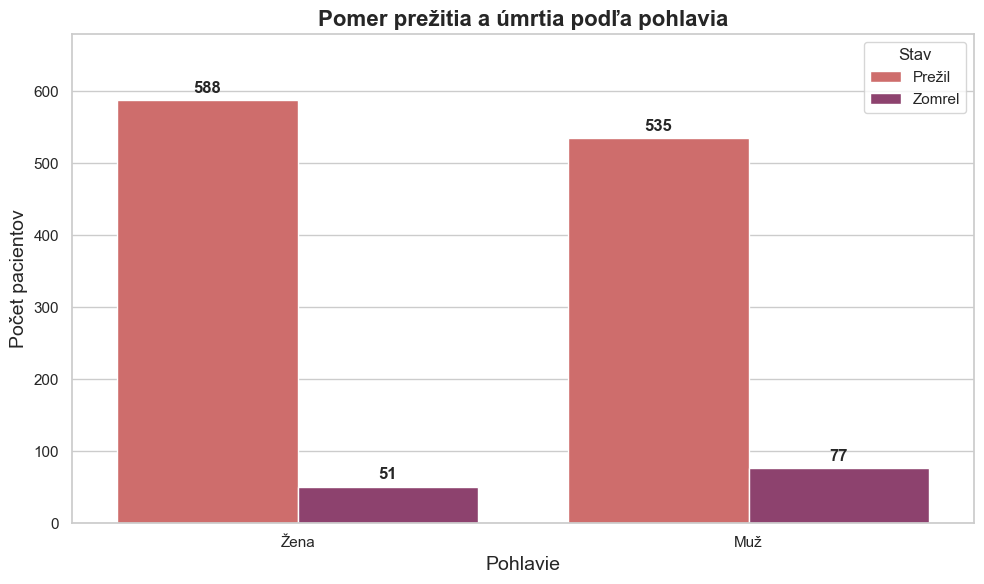

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=vlna_4, x="Pohlavie", hue="Zomrel", ax=ax, palette='flare')

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3, fontweight='bold')

ax.set_xlabel("Pohlavie", fontsize=14)
ax.set_ylabel("Počet pacientov", fontsize=14)
ax.set_title("Pomer prežitia a úmrtia podľa pohlavia", fontsize=16, fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Prežil', 'Zomrel'], title="Stav", loc='upper right')

ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===================================================================
# NASTAVENIE PRE KONKRÉTNU VLNU

aktualna_vlna = vlna_4  
nazov_grafu = 'Výskyt komorbidít podľa pohlavia a stavu prežitia (4. Vlna)'

# Zoznam stĺpcov diagnóz, ktoré chceme vizualizovať
komorbidity_list = ['Kardiovaskulárne ochorenia', 'Hypertenzia', 'Renálne ochorenia', 
                    'Diabetes mellitus', 'Chronické respiračné ochorenia', 
                    'Onkologické ochorenia', 'A04.7', 'Pečeňové ochorenia']

# ===================================================================
# 1. PRÍPRAVA DÁT
df_subset = aktualna_vlna[komorbidity_list + ['Zomrel', 'Pohlavie']].copy()
 
df_subset['Zomrel'] = df_subset['Zomrel'].map({0: 'Prežil', 1: 'Zomrel'})

df_melted = df_subset.melt(id_vars=['Zomrel', 'Pohlavie'], var_name='Komorbidita', value_name='Vyskyt')

# Vyfiltrujeme len pacientov s chorobou
df_plot = df_melted[df_melted['Vyskyt'] == True].copy()

# Zistíme celkový počet výskytov
counts = df_plot['Komorbidita'].value_counts()

# ===================================================================
# 2. VYKRESLENIE GRAFU
g = sns.catplot(
    data=df_plot, y='Komorbidita', hue='Zomrel', col='Pohlavie',
    kind='count', 
    hue_order=['Prežil', 'Zomrel'], 
    palette={'Prežil': '#e08f8f', 'Zomrel': '#8a3d63'}, 
    order=counts.index,
    height=8, aspect=0.8, legend=False 
)

for ax in g.axes.flat:
    for p in ax.patches:
        width = p.get_width()
        if not np.isnan(width) and width > 0:
            ax.annotate(f'{int(width)}', 
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', xytext=(3, 0), 
                        textcoords='offset points', fontsize=9, fontweight='bold')

g.set_axis_labels("", "Diagnóza", ha='center', fontsize=14, fontweight='bold')
g.set_titles("{col_name}", fontweight='bold') 

g.fig.text(0.5, 0.02, 'Počet pacientov', ha='center', fontsize=14, fontweight='bold')

g.fig.suptitle(nazov_grafu, fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.90, bottom=0.1) 

plt.legend(title='Stav pacienta', loc='lower right')
plt.legend(title='Stav', labels=['Prežil', 'Zomrel']) 
plt.show()